# Fig.12：方案 A 的逐壳原始累计并合数

本 Notebook 调用 `binary_single_montecarlo.py`、`binary_single.py`、`halostructure.py` 和 `p_a_j.py`，不在 Notebook 中复制物理公式。目标是检查论文 Fig.12 的**未按真实壳层人口重加权**的十条累计曲线。原图对应 $M_0=1.15\times10^{12}M_\odot$，每壳每时间片抽取 $2\times10^6$ 个双星。

本次试运行明确采用：方案 A（每时间片独立重抽、无 cohort 继承）；Appendix D 严格联合分布；Prada12-HMF halo；$\rho_{\rm env}=\rho_{\rm NFW}$、$v_{\rm env}=\sqrt{0.5GM(<r)/r}$；当前 `binary_single.py` 的 Sesana $K(a/a_h,e)$ 插值与 $e>0.9$ 端点规则；全局 200 Myr、局部 Euler 2 Myr。以上并非论文原始 Ludlow16 运行。


## 原图与时间片口径

原图 Fig.12 的横轴是从模拟起点算起的 $t$（Myr），纵轴为对数刻度的累计 $N_{\rm merger}$，曲线 $R_1$ 至 $R_{10}$ 分别代表十个壳层。论文说因对**相邻时间片的并合率**做平均而舍弃第一时间片，使后面的率图从约 $z\simeq10$ 显示；Fig.12 是原始累计事件数，不做这个率平均，也不删除第一时间片。按本次 Prada 宇宙学，首个 200 Myr 时间片的中点约为 $z=10.13$，末边界约为 $z=8.82$：$z\simeq10$ 更接近中点，而不是 200 Myr 末边界。

论文未公开随机种子及原始样本，本试运行用固定种子。默认每壳每步仅 5,000 样本，属于试算，不是论文 $2\times10^6$ 样本的定量复现。可以在下方提高样本数，但计算量按样本数显著增长。


In [1]:
from dataclasses import asdict
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'binary_single_montecarlo.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from binary_single import BinarySingleConfig
from binary_single_montecarlo import run_raw_shell_monte_carlo, redshift_from_cosmic_age_myr
import haloconcentration as hc
from p_a_j import AppendixDOrbitalDistribution

OUTPUT_DIR = PROJECT_ROOT / 'pic_and_data'
OUTPUT_DIR.mkdir(exist_ok=True)
HALO_M0_MSUN = 1.15e12
SAMPLES_PER_SHELL_AND_STEP = 5_000  # 论文生产设置：2_000_000
CHUNK_SIZE = 5_000
RANDOM_SEED = 20260922

config = BinarySingleConfig(
    halo_model='prada12_hmf_sigma',
    primary_mass_msun=30.0,
    secondary_mass_msun=30.0,
    pbh_fraction_total=1.0,
    velocity_mu=0.5,
    ksi=1.0,
    global_timestep_myr=200.0,
    local_timestep_myr=2.0,
    start_redshift=12.0,
    sample_count_per_shell_and_step=SAMPLES_PER_SHELL_AND_STEP,
)
orbital_distribution = AppendixDOrbitalDistribution(
    pbh_mass_msun=30.0, f_pbh=1.0,
)
print('严格联合采样；Prada12-HMF；方案 A 独立重抽')
print('每壳每步样本数:', SAMPLES_PER_SHELL_AND_STEP, '随机种子:', RANDOM_SEED)


严格联合采样；Prada12-HMF；方案 A 独立重抽
每壳每步样本数: 5000 随机种子: 20260922


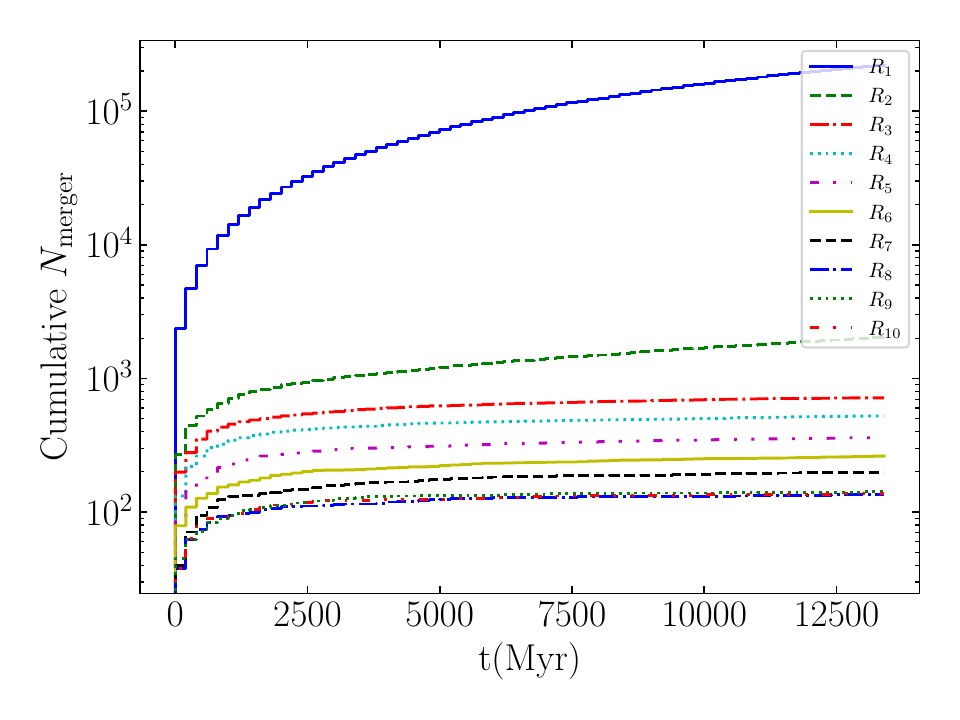

In [2]:
reference_png = OUTPUT_DIR / 'fig12_paper_reference.png'
if reference_png.exists():
    display(Image(filename=str(reference_png)))
else:
    print('原图参考：tmp/arxiv_2408.06515v2_source/Merger3body_N1.1_c_v1.pdf')


In [3]:
result = run_raw_shell_monte_carlo(
    present_day_halo_mass_msun=HALO_M0_MSUN,
    config=config,
    orbital_distribution=orbital_distribution,
    random_seed=RANDOM_SEED,
    chunk_size=CHUNK_SIZE,
)
print(f'实际起点 z={result.start_redshift_used:.6g}；时间片={result.time_step_count}；壳层={result.shell_count}')
first_midpoint_age = 0.5 * (result.time_edges_myr[0] + result.time_edges_myr[1])
first_midpoint_z = float(redshift_from_cosmic_age_myr(first_midpoint_age, hc.cosmology_for_model(config.halo_model)))
print(f'首片中点 z={first_midpoint_z:.3f}；首片末边界 z={result.redshift_edges[1]:.3f}')
print(f'总抽样={result.sampled_per_step.sum():,}；硬双星={result.hard_per_step.sum():,}；并合={result.mergers_per_step.sum():,}')
hard_total = int(result.hard_per_step.sum())
invalid_total = int(result.invalid_per_step.sum())
k_endpoint_total = int(result.k_above_calibration_per_step.sum())
print(f'数值失效={invalid_total:,}（占硬双星 {invalid_total / hard_total:.1%}）')
print(f'使用 K 的 e>0.9 端点={k_endpoint_total:,}（占硬双星 {k_endpoint_total / hard_total:.1%}）')
print('各壳最终原始累计并合数:', result.cumulative_mergers[-1].tolist())


实际起点 z=12；时间片=68；壳层=10
首片中点 z=10.133；首片末边界 z=8.818
总抽样=3,400,000；硬双星=415,033；并合=117,662
数值失效=118,810（占硬双星 28.6%）
使用 K 的 e>0.9 端点=373,778（占硬双星 90.1%）
各壳最终原始累计并合数: [31172, 36700, 19516, 14889, 8011, 3704, 1577, 836, 590, 667]


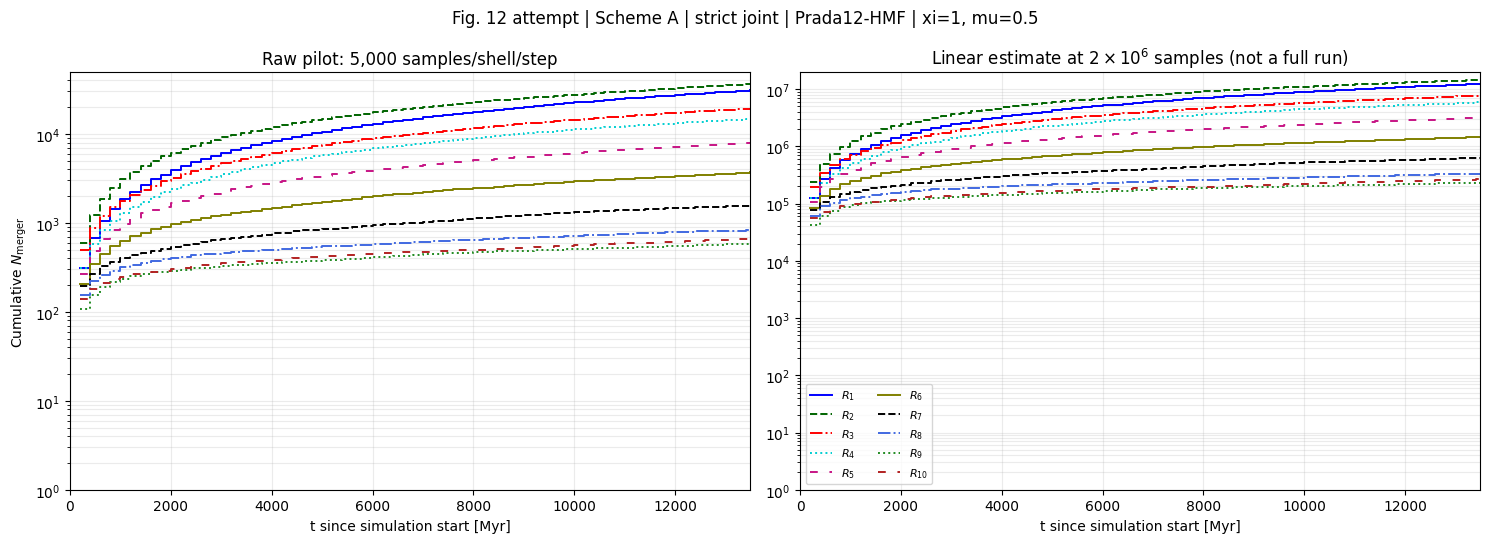

D:\pbh formation\pbh merge\2body channel and numerical simulation\pic_and_data\fig12_schemeA_strict_prada12_hmf_pilot.png


In [4]:
elapsed_myr = result.elapsed_time_edges_myr
raw_cumulative = result.cumulative_mergers
paper_sample_count = 2_000_000
equivalent_cumulative = raw_cumulative * (paper_sample_count / SAMPLES_PER_SHELL_AND_STEP)
colors = ['blue', 'darkgreen', 'red', 'darkturquoise', 'mediumvioletred', 'olive', 'black', 'royalblue', 'forestgreen', 'firebrick']
styles = ['-', '--', '-.', ':', (0, (4, 6)), '-', '--', '-.', ':', (0, (4, 6))]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)
for shell in range(result.shell_count):
    label = fr'$R_{{{shell + 1}}}$'
    for ax, values in zip(axes, (raw_cumulative, equivalent_cumulative)):
        y = np.where(values[:, shell] > 0, values[:, shell], np.nan)
        ax.step(elapsed_myr, y, where='post', color=colors[shell], linestyle=styles[shell], linewidth=1.4, label=label)
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(0, elapsed_myr[-1])
    ax.set_ylim(bottom=1)
    ax.set_xlabel('t since simulation start [Myr]')
    ax.grid(alpha=0.25, which='both')
axes[0].set_ylabel(r'Cumulative $N_{\rm merger}$')
axes[0].set_title(f'Raw pilot: {SAMPLES_PER_SHELL_AND_STEP:,} samples/shell/step')
axes[1].set_title(r'Linear estimate at $2\times10^6$ samples (not a full run)')
axes[1].legend(ncol=2, fontsize=8, loc='best')
fig.suptitle('Fig. 12 attempt | Scheme A | strict joint | Prada12-HMF | xi=1, mu=0.5')
fig.tight_layout()
FIGURE_PNG = OUTPUT_DIR / 'fig12_schemeA_strict_prada12_hmf_pilot.png'
fig.savefig(FIGURE_PNG, dpi=180)
plt.show()
print(FIGURE_PNG)


In [5]:
columns = ['elapsed_time_myr', 'redshift'] + [f'R{i}_cumulative_raw' for i in range(1, result.shell_count + 1)]
data = np.column_stack((elapsed_myr, result.redshift_edges, raw_cumulative))
CURVE_CSV = OUTPUT_DIR / 'fig12_schemeA_strict_prada12_hmf_pilot.csv'
np.savetxt(CURVE_CSV, data, delimiter=',', header=','.join(columns), comments='')

step_columns = ['t_end_myr', 'z_start', 'z_end']
for prefix in ('sampled', 'hard', 'merged', 'invalid', 'K_above_e09'):
    step_columns.extend(f'R{i}_{prefix}' for i in range(1, result.shell_count + 1))
step_data = np.column_stack((
    elapsed_myr[1:], result.redshift_edges[:-1], result.redshift_edges[1:],
    result.sampled_per_step, result.hard_per_step, result.mergers_per_step,
    result.invalid_per_step, result.k_above_calibration_per_step,
))
COUNTS_CSV = OUTPUT_DIR / 'fig12_schemeA_strict_prada12_hmf_counts.csv'
np.savetxt(COUNTS_CSV, step_data, delimiter=',', header=','.join(step_columns), comments='')

metadata = {
    'figure': 'Fig.12 pilot; raw counts and a separately labelled linear sample-size estimate',
    'scheme': 'A: independent resampling for each time bin',
    'sampling': 'strict Appendix D joint distribution, a marginal then j conditional on a',
    'K_policy': 'Sesana q=1 Table 3; interpolate K in e; e>0.9 endpoint',
    'halo_mass_M0_msun': HALO_M0_MSUN,
    'config': asdict(config),
    'orbital_distribution': asdict(orbital_distribution),
    'random_seed': RANDOM_SEED,
    'chunk_size': CHUNK_SIZE,
    'start_redshift_used': result.start_redshift_used,
    'time_step_count': result.time_step_count,
    'last_global_step_myr': float(np.diff(result.time_edges_myr)[-1]),
    'invalid_count': int(result.invalid_per_step.sum()),
}
CONFIG_JSON = OUTPUT_DIR / 'fig12_schemeA_strict_prada12_hmf_config.json'
CONFIG_JSON.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
print('已保存:', FIGURE_PNG.name, CURVE_CSV.name, COUNTS_CSV.name, CONFIG_JSON.name)


已保存: fig12_schemeA_strict_prada12_hmf_pilot.png fig12_schemeA_strict_prada12_hmf_pilot.csv fig12_schemeA_strict_prada12_hmf_counts.csv fig12_schemeA_strict_prada12_hmf_config.json


## 阅读本次尝试的边界

左图是真实抽到的试运行原始累计事件数；右图只是乘以 $2\times10^6/N_{\rm pilot}$ 后的期望量级估计，不会降低小样本的 Poisson/Monte Carlo 噪声。当前 5,000 样本试算的 $R_2$ 终点高于 $R_1$，而原图由 $R_1$ 主导；换算后的绝对幅度也明显偏高。尤其需要先处理输出中的数值失效占比，不能把失败样本当作真实未并合样本。

默认轨道采样器的 $\rho_{\rm eq}$ 仍采用 `p_a_j.py` 的 Planck 参数默认值；Prada12-HMF 只控制这里的 halo 吸积与结构。$K$ 的 $e>0.9$ 端点规则是本项目选择，不是 Sesana 表 3 的原始拟合区间。

方案 B（cohort 继承）、真实壳层双星人口重加权、率的相邻时间片平均、舍弃率曲线首片、HMF 积分，均不属于 Fig.12 的本次试运行。
